# Combine the datasets into a single cube for a region of interest (ROI)

This notebook shows the conversion pattern behind the remote Antarctica cubes on a compact region of interest. It reads the same styles of source used by the access notebooks: existing Zarr grids, vector Parquet layers, and a raster COG/GeoTIFF. Each source is transformed onto one EPSG:3031 grid and merged into a single local Zarr cube.

The example uses a 80 km by 80 km Amundsen Sea  at 200 m grid spacing to demonstrate dataset merging and interpolation patterns.


## Setup

The constants define the target grid, output paths, and anonymous CloudFerro S3 access used by the source notebooks.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import json
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import xarray as xr
from dask.diagnostics import ProgressBar
from pyproj import CRS, Transformer
from rasterio import features
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from rasterio.warp import reproject, transform_bounds
from scipy.spatial import cKDTree
from shapely.geometry import box

pd.set_option("display.max_colwidth", 120)

TARGET_CRS = "EPSG:3031"
AOI_CENTER_XY_M = (-1_600_000.0, -350_000.0)
AOI_WIDTH_M = 80_000
TARGET_RESOLUTION_M = 200
VELOCITY_TIME_TARGET = "2019-01-01"
ICE_TEMPERATURE_DEPTH_M = 1_000

NOTEBOOK_DIR = Path("remote_cubes") if Path("remote_cubes").exists() else Path(".")
OUTPUT_DIR = NOTEBOOK_DIR / "demo_outputs"
LAYER_DIR = OUTPUT_DIR / "layers"
FINAL_CUBE = OUTPUT_DIR / "amundsen_100m_demo_cube.zarr"

S3_OPTIONS = {
    "anon": True,
    "client_kwargs": {
        "endpoint_url": "https://s3.waw4-1.cloudferro.com",
        "region_name": "eu-west-2",
    },
}


## Source Products

The access notebooks fall into four source groups: regular Zarr grids, a curvilinear Zarr temperature grid, vector/table GeoParquet, and a basal-melt raster. The remote-cube notebook shows the target pattern: many variables on shared `y, x` coordinates. Here we rebuild that idea for one small ROI instead of reading a prebuilt combined cube.


In [2]:
SOURCES = {
    "bedmachine_zarr": "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/bedrock_topography/NSIDC-0756_BedMachineAntarctica_19700101-20191001_V04.1.zarr/",
    "sec_zarr": "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/surface_elevation/ESACCI-AIS-L3C-SEC-MULTIMISSION-5KM-5YEAR-MEANS-1991-2021-fv1.zarr/",
    "ice_velocity_zarr": "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/ice_velocity/ice_velocity.zarr/",
    "ice_temperature_zarr": "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/ice_sheet_temperature/SM_TEST_MIR_ITUDP4_20130101T000000_20141231T000000_200_001_0.zarr/",
    "basal_melt_cog": "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/basal_melt/basal_melt_map_racmo_firn_air_corrected.tif",
    "groundlines_parquet": "s3://EarthCODE/OSCAssets/polar_cube_datasets/groundlines/InSAR_GL_Antarctica.parquet",
    "supraglacial_lakes_parquet": "s3://EarthCODE/OSCAssets/polar_cube_datasets/supraglacial_lakes/WAIS_Jan_2017_Polygons.parquet",
    "subglacial_lakes_parquet": "s3://EarthCODE/OSCAssets/polar_cube_datasets/subglacial_lakes/subglacial_lakes_boundries.parquet",
    "calving_fronts_parquet": "s3://EarthCODE/OSCAssets/polar_cube_datasets/calving_fronts/Antarctic_coastlines.parquet",
}

pd.DataFrame.from_dict(SOURCES, orient="index", columns=["source"])


,source
bedmachine_zarr,https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/bedrock_topography/NSIDC-0756_BedMachineAnt...
sec_zarr,https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/surface_elevation/ESACCI-AIS-L3C-SEC-MULTIM...
ice_velocity_zarr,https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/ice_velocity/ice_velocity.zarr/
ice_temperature_zarr,https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/ice_sheet_temperature/SM_TEST_MIR_ITUDP4_20...
basal_melt_cog,https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/basal_melt/basal_melt_map_racmo_firn_air_co...
groundlines_parquet,s3://EarthCODE/OSCAssets/polar_cube_datasets/groundlines/InSAR_GL_Antarctica.parquet
supraglacial_lakes_parquet,s3://EarthCODE/OSCAssets/polar_cube_datasets/supraglacial_lakes/WAIS_Jan_2017_Polygons.parquet
subglacial_lakes_parquet,s3://EarthCODE/OSCAssets/polar_cube_datasets/subglacial_lakes/subglacial_lakes_boundries.parquet
calving_fronts_parquet,s3://EarthCODE/OSCAssets/polar_cube_datasets/calving_fronts/Antarctic_coastlines.parquet


## Target Grid

The grid is defined once and then reused by every handler. Coordinates are cell centres; the affine transform describes the cell edges used by rasterio.


In [3]:
@dataclass(frozen=True)
class TargetGrid:
    x: np.ndarray
    y: np.ndarray
    transform: rasterio.Affine
    resolution_m: int
    crs: str = TARGET_CRS

    @property
    def shape(self) -> tuple[int, int]:
        return (self.y.size, self.x.size)

    @property
    def bounds(self) -> tuple[float, float, float, float]:
        left = float(self.x.min() - self.resolution_m / 2)
        right = float(self.x.max() + self.resolution_m / 2)
        bottom = float(self.y.min() - self.resolution_m / 2)
        top = float(self.y.max() + self.resolution_m / 2)
        return left, bottom, right, top

    @property
    def coords(self) -> dict[str, tuple[str, np.ndarray, dict[str, str]]]:
        return {
            "y": ("y", self.y, {"standard_name": "projection_y_coordinate", "units": "m"}),
            "x": ("x", self.x, {"standard_name": "projection_x_coordinate", "units": "m"}),
        }

    def template(self) -> xr.Dataset:
        crs = CRS.from_user_input(self.crs)
        return xr.Dataset(
            coords=self.coords,
            data_vars={"spatial_ref": xr.DataArray(0, attrs={"crs_wkt": crs.to_wkt(), "spatial_ref": crs.to_wkt()})},
            attrs={"crs": self.crs, "resolution_m": self.resolution_m},
        )


In [4]:
def make_target_grid(center_xy: tuple[float, float], width_m: int, resolution_m: int) -> TargetGrid:
    center_x, center_y = center_xy
    half = width_m / 2
    left, right = center_x - half, center_x + half
    bottom, top = center_y - half, center_y + half

    nx = int(round(width_m / resolution_m))
    ny = int(round(width_m / resolution_m))
    x = left + resolution_m / 2 + np.arange(nx) * resolution_m
    y = top - resolution_m / 2 - np.arange(ny) * resolution_m
    transform = from_origin(left, top, resolution_m, resolution_m)
    return TargetGrid(x=x, y=y, transform=transform, resolution_m=resolution_m)

TARGET = make_target_grid(AOI_CENTER_XY_M, AOI_WIDTH_M, TARGET_RESOLUTION_M)
TARGET.template()


<xarray.Dataset> Size: 6kB
Dimensions:      (y: 400, x: 400)
Coordinates:
  * y            (y) float64 3kB -3.101e+05 -3.103e+05 ... -3.897e+05 -3.899e+05
  * x            (x) float64 3kB -1.64e+06 -1.64e+06 ... -1.56e+06 -1.56e+06
Data variables:
    spatial_ref  int64 8B 0
Attributes:
    crs:           EPSG:3031
    resolution_m:  200

/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


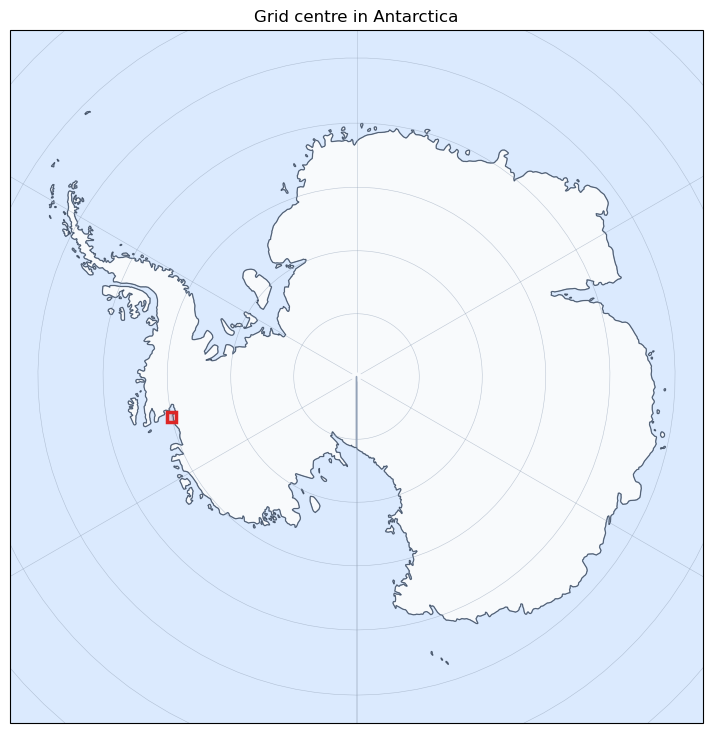

In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

antarctic_crs = ccrs.SouthPolarStereo(
    central_longitude=0,
    true_scale_latitude=-71,
)

left, bottom, right, top = TARGET.bounds
cell = TARGET.resolution_m
cx, cy = AOI_CENTER_XY_M

fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=antarctic_crs)

ax.set_xlim(-3_000_000, 3_000_000)
ax.set_ylim(-3_000_000, 3_000_000)

for axis in [ax]:
    axis.add_feature(cfeature.OCEAN, facecolor="#dbeafe", zorder=0)
    axis.add_feature(cfeature.LAND, facecolor="#f8fafc", edgecolor="#94a3b8", zorder=1)
    axis.add_feature(cfeature.COASTLINE, linewidth=0.6, color="#475569", zorder=2)

ax.gridlines(draw_labels=False, linewidth=0.4, color="#94a3b8", alpha=0.6)

# Transparent ROI footprint.
ax.add_patch(
    Rectangle(
        (left, bottom),
        right - left,
        top - bottom,
        facecolor="#dc262620",
        edgecolor="#dc2626",
        linewidth=2.5,
        transform=antarctic_crs,
        zorder=5,
    )
)

ax.set_title("Grid centre in Antarctica")

plt.show()

## Shared Zarr Helpers

These helpers keep the workflow repeatable: open remote Zarr lazily, write local Zarr stores, and preserve CRS metadata.


In [6]:
def open_remote_zarr(url: str) -> xr.Dataset:
    last_error = None
    for consolidated in (True, False):
        kwargs = dict(consolidated=consolidated, chunks={})
        try:
            return xr.open_zarr(url, create_default_indexes=False, **kwargs)
        except TypeError:
            try:
                return xr.open_zarr(url, **kwargs)
            except Exception as exc:
                last_error = exc
        except Exception as exc:
            last_error = exc
    raise last_error


def write_zarr(ds: xr.Dataset, path: Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    chunks = {dim: min(size, 256) for dim, size in ds.sizes.items() if dim in {"y", "x"}}
    ds_out = ds.chunk(chunks) if chunks else ds

    with ProgressBar():
        try:
            ds_out.to_zarr(path, mode="w", consolidated=True, zarr_format=2)
        except TypeError:
            ds_out.to_zarr(path, mode="w", consolidated=True, zarr_version=2)
    return path


## Generic Interpolation

`interpolate_to_grid` works for `DataArray` or `Dataset` objects with `x` and `y` coordinates. Use `nearest` for masks/classes, and `linear` for continuous fields where smoothing is acceptable.


In [7]:
def _coord_slice(coord: xr.DataArray, lower: float, upper: float) -> slice:
    values = np.asarray(coord.values)
    return slice(lower, upper) if values[0] <= values[-1] else slice(upper, lower)


def subset_xy_window(obj: xr.Dataset | xr.DataArray, grid: TargetGrid, pad_m: int = 0):
    left, bottom, right, top = grid.bounds
    return obj.sel(
        x=_coord_slice(obj["x"], left - pad_m, right + pad_m),
        y=_coord_slice(obj["y"], bottom - pad_m, top + pad_m),
    )


def interpolate_to_grid(obj: xr.Dataset | xr.DataArray, grid: TargetGrid, method: str = "nearest"):
    source = obj.sortby("x").sortby("y")
    target = grid.template()
    out = source.interp(x=target["x"], y=target["y"], method=method)
    out = out.assign_coords(x=target["x"], y=target["y"])
    out.attrs.update(obj.attrs)
    out.attrs["interpolation_method"] = method
    return out


## Curvilinear Nearest Neighbour

The ice-temperature product stores latitude and longitude arrays instead of regular `x, y` coordinates. This helper follows the access notebook: project those points to EPSG:3031, build a KDTree, and copy the nearest source value to each target cell.


In [8]:
def nearest_index(coord: xr.DataArray, target: float) -> int:
    values = np.asarray(coord.values)
    return int(np.nanargmin(np.abs(values - target)))


def curvilinear_nearest_to_grid(
    values: np.ndarray,
    longitude: np.ndarray,
    latitude: np.ndarray,
    grid: TargetGrid,
    name: str,
    source_crs: str = "EPSG:4326",
) -> xr.DataArray:
    lon = ((np.asarray(longitude) + 180) % 360) - 180
    lat = np.asarray(latitude)
    source_x, source_y = Transformer.from_crs(source_crs, grid.crs, always_xy=True).transform(lon, lat)

    valid = np.isfinite(source_x) & np.isfinite(source_y) & np.isfinite(lat) & np.isfinite(lon)
    source_points = np.column_stack([source_x[valid], source_y[valid]])

    target_xx, target_yy = np.meshgrid(grid.x, grid.y)
    target_points = np.column_stack([target_xx.ravel(), target_yy.ravel()])
    _, nearest = cKDTree(source_points).query(target_points, k=1)

    data = np.asarray(values)[valid][nearest].reshape(grid.shape).astype("float32")
    da = xr.DataArray(data, dims=("y", "x"), coords=grid.coords, name=name)
    da.attrs.update({"grid_mapping": "spatial_ref", "interpolation_method": "nearest"})
    return da


## Parquet To Raster To Zarr

The vector handler reads GeoParquet, clips to the AOI, rasterises geometries onto the target grid, and can write the resulting single-layer Zarr store.


In [9]:
def read_geoparquet(path: str, geometry: str | None = None) -> gpd.GeoDataFrame:
    kwargs = {"storage_options": S3_OPTIONS} if path.startswith("s3://") else {}
    gdf = gpd.read_parquet(path, **kwargs)
    return gdf.set_geometry(geometry) if geometry else gdf


def clip_geodataframe(gdf: gpd.GeoDataFrame, grid: TargetGrid, source_crs: str = TARGET_CRS) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        gdf = gdf.set_crs(source_crs)
    gdf = gdf.to_crs(grid.crs)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty]

    aoi = box(*grid.bounds)
    clipped = gdf.loc[gdf.intersects(aoi)].copy()
    if clipped.empty:
        return clipped

    clipped[clipped.geometry.name] = clipped.geometry.intersection(aoi)
    return clipped[~clipped.geometry.is_empty].reset_index(drop=True)


In [10]:
def rasterize_vectors(
    gdf: gpd.GeoDataFrame,
    grid: TargetGrid,
    name: str,
    value_column: str | None = None,
    dtype: str = "uint16",
    all_touched: bool = True,
) -> xr.DataArray:
    attrs = {"grid_mapping": "spatial_ref", "source_type": "geoparquet", "rasterized": "true"}

    if value_column is None or gdf.empty:
        values = np.ones(len(gdf), dtype="uint16")
    elif pd.api.types.is_numeric_dtype(gdf[value_column]):
        values = gdf[value_column].fillna(0).to_numpy()
    else:
        codes, labels = pd.factorize(gdf[value_column].astype("string"), sort=True)
        values = codes + 1
        attrs["value_mapping_json"] = json.dumps({str(i + 1): str(label) for i, label in enumerate(labels)})

    shape_values = [(geom, value) for geom, value in zip(gdf.geometry, values) if geom is not None and not geom.is_empty]
    arr = np.zeros(grid.shape, dtype=dtype)
    if shape_values:
        arr = features.rasterize(shape_values, out_shape=grid.shape, transform=grid.transform, fill=0, dtype=dtype, all_touched=all_touched)

    return xr.DataArray(arr, dims=("y", "x"), coords=grid.coords, name=name, attrs=attrs)


In [11]:
def parquet_to_raster_layer(
    path: str,
    grid: TargetGrid,
    name: str,
    value_column: str | None = None,
    geometry: str | None = None,
    write_to: Path | None = None,
) -> tuple[xr.DataArray, gpd.GeoDataFrame]:
    gdf = read_geoparquet(path, geometry=geometry)
    clipped = clip_geodataframe(gdf, grid)
    layer = rasterize_vectors(clipped, grid, name=name, value_column=value_column)

    if write_to is not None:
        write_zarr(layer.to_dataset(), write_to)
    print(f"{name}: {len(clipped):,} features intersect the AOI")
    return layer, clipped


## COG To Zarr

The raster handler reads only the source window intersecting the target bounds, reprojects it onto the EPSG:3031 grid, and optionally writes a single-layer Zarr store.


In [12]:
def rasterio_resampling(method: str) -> Resampling:
    try:
        return Resampling[method]
    except KeyError as exc:
        valid = ", ".join(item.name for item in Resampling)
        raise ValueError(f"Unknown rasterio resampling '{method}'. Valid options include: {valid}") from exc


def cog_to_zarr_layer(path: str, grid: TargetGrid, name: str, method: str = "nearest", band: int = 1, write_to: Path | None = None) -> xr.DataArray:
    with rasterio.open(path) as src:
        src_bounds = transform_bounds(grid.crs, src.crs, *grid.bounds, densify_pts=21) if src.crs else grid.bounds
        window = rasterio.windows.from_bounds(*src_bounds, transform=src.transform).round_offsets().round_lengths()
        src_data = src.read(band, window=window, boundless=True, masked=True)
        src_transform = src.window_transform(window)
        source = src_data.filled(np.nan).astype("float32")

        dest = np.full(grid.shape, np.nan, dtype="float32")
        reproject(
            source=source,
            destination=dest,
            src_transform=src_transform,
            src_crs=src.crs,
            src_nodata=np.nan,
            dst_transform=grid.transform,
            dst_crs=grid.crs,
            dst_nodata=np.nan,
            resampling=rasterio_resampling(method),
        )

    da = xr.DataArray(dest, dims=("y", "x"), coords=grid.coords, name=name)
    da.attrs.update({"grid_mapping": "spatial_ref", "source_type": "cog", "interpolation_method": method})
    if write_to is not None:
        write_zarr(da.to_dataset(), write_to)
    return da


## BedMachine Layer

BedMachine is already gridded. For the demo cube we use nearest-neighbour interpolation so the 100 m layer preserves source classes and values. Thickness above flotation is derived after regridding.


In [13]:
bedmachine = open_remote_zarr(SOURCES["bedmachine_zarr"])
bedmachine = bedmachine.set_index({'x':'x', 'y': 'y'})

bedmachine_roi = subset_xy_window(
    bedmachine[["bed", "thickness", "mask"]],
    TARGET,
    pad_m=2_000,
)

bed_layer = interpolate_to_grid(
    bedmachine_roi,
    TARGET,
    method="nearest",
)

bed_layer = bed_layer.rename(
    {
        "bed": "bedrock_elevation",
        "thickness": "ice_thickness",
        "mask": "bedmachine_mask",
    }
)

bed_layer["bedmachine_mask"] = bed_layer["bedmachine_mask"].round().fillna(0).astype("uint8")
bed_layer["bedrock_elevation"] = bed_layer["bedrock_elevation"].astype("float32")
bed_layer["ice_thickness"] = bed_layer["ice_thickness"].astype("float32")

rho_ice = 917.0
rho_water = 1027.0

flotation_thickness = xr.where(
    bed_layer["bedrock_elevation"] < 0,
    -(rho_water / rho_ice) * bed_layer["bedrock_elevation"],
    0.0,
)

grounded_marine_ice = (
    (bed_layer["bedmachine_mask"] == 2)
    & (bed_layer["bedrock_elevation"] < 0)
)

bed_layer["thickness_above_flotation"] = (
    bed_layer["ice_thickness"] - flotation_thickness
).where(grounded_marine_ice).astype("float32")

bed_layer.attrs.update(
    source_type="zarr",
    interpolation_method="nearest",
)

bed_layer


<xarray.Dataset> Size: 2MB
Dimensions:                    (y: 400, x: 400)
Coordinates:
  * x                          (x) float64 3kB -1.64e+06 -1.64e+06 ... -1.56e+06
  * y                          (y) float64 3kB -3.101e+05 ... -3.899e+05
Data variables:
    bedrock_elevation          (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ice_thickness              (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    bedmachine_mask            (y, x) uint8 160kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    thickness_above_flotation  (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                 CF-1.7, ACDD-1.3
    title:                       BedMachine Antarctica v4
    creator_name:                Mathieu Morlighem
    creator_email:               mathieu.morlighem@dartmouth.edu
    creator_institution:         Department of Earth and Planetary Sciences, ...
    product_version:             v4.1
    ...                          ...
    summary:                     This dataset contains a bed topography/bathy...
    time_coverage_start:         1970-01-01
    time_coverage_end:           2019-10-01
    nominal_year:                2015
    interpolation_method:        nearest
    source_type:                 zarr

## Basal Melt COG Layer

Basal melt is a continuous raster, so this layer uses bilinear resampling instead of nearest neighbour.


In [14]:
basal_melt = cog_to_zarr_layer(
    SOURCES["basal_melt_cog"],
    TARGET,
    name="ice_shelf_basal_melt_rate",
    method="nearest",
    write_to=None,
)
basal_melt


<xarray.DataArray 'ice_shelf_basal_melt_rate' (y: 400, x: 400)> Size: 640kB
array([[0.95849395, 0.95849395, 0.95849395, ...,        nan,        nan,
               nan],
       [0.95849395, 0.95849395, 0.95849395, ...,        nan,        nan,
               nan],
       [0.95849395, 0.95849395, 0.95849395, ...,        nan,        nan,
               nan],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], shape=(400, 400), dtype=float32)
Coordinates:
  * y        (y) float64 3kB -3.101e+05 -3.103e+05 ... -3.897e+05 -3.899e+05
  * x        (x) float64 3kB -1.64e+06 -1.64e+06 ... -1.56e+06 -1.56e+06
Attributes:
    grid_mapping:          spatial_ref
    source_type:           cog
    interpolation_method:  nearest

## Vector Mask Layers

Vector products are rasterised directly on the target grid. These masks use nearest-style class assignment because line and polygon identity should not be smoothed.


In [15]:
vector_specs = [
    ("groundlines_parquet", "grounding_line_mask", None),
    ("supraglacial_lakes_parquet", "supraglacial_lake_mask", None),
    ("subglacial_lakes_parquet", "subglacial_lake_mask", None),
]

vector_layers = []
feature_counts = {}
for key, name, value_column in vector_specs:
    layer, clipped = parquet_to_raster_layer(
        SOURCES[key],
        TARGET,
        name=name,
        value_column=value_column,
        write_to=LAYER_DIR / f"{name}_100m.zarr",
    )
    vector_layers.append(layer)
    feature_counts[name] = len(clipped)

pd.Series(feature_counts, name="features_in_aoi")


[########################################] | 100% Completed | 101.59 ms
grounding_line_mask: 9 features intersect the AOI
[########################################] | 100% Completed | 101.45 ms
supraglacial_lake_mask: 0 features intersect the AOI
[########################################] | 100% Completed | 101.73 ms
subglacial_lake_mask: 0 features intersect the AOI


grounding_line_mask       9
supraglacial_lake_mask    0
subglacial_lake_mask      0
Name: features_in_aoi, dtype: int64

## Latest Calving-Front Mask

The calving-front access notebook is time-aware. For one cube layer, select the latest available coastline before rasterising.


In [16]:
calving_gdf = read_geoparquet(SOURCES["calving_fronts_parquet"])
calving_gdf["time"] = pd.to_datetime(calving_gdf["time"])
latest_time = calving_gdf["time"].max()
latest_calving = calving_gdf.loc[calving_gdf["time"] == latest_time]

calving_clipped = clip_geodataframe(latest_calving, TARGET)
calving_mask = rasterize_vectors(calving_clipped, TARGET, name="calving_front_mask", dtype="uint8")
calving_mask.attrs["selected_time"] = latest_time.isoformat()

print(f"calving_front_mask: {len(calving_clipped):,} latest features intersect the AOI")
calving_mask


calving_front_mask: 1 latest features intersect the AOI


<xarray.DataArray 'calving_front_mask' (y: 400, x: 400)> Size: 160kB
array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]], shape=(400, 400), dtype=uint8)
Coordinates:
  * y        (y) float64 3kB -3.101e+05 -3.103e+05 ... -3.897e+05 -3.899e+05
  * x        (x) float64 3kB -1.64e+06 -1.64e+06 ... -1.56e+06 -1.56e+06
Attributes:
    grid_mapping:   spatial_ref
    source_type:    geoparquet
    rasterized:     true
    selected_time:  2021-03-15T00:00:00

## Surface Elevation Change Layer

SEC is a coarse continuous grid. The rate and uncertainty use linear interpolation; the surface-type class uses nearest neighbour.


In [17]:
sec = open_remote_zarr(SOURCES["sec_zarr"])
sec_latest = sec[["sec", "sec_uncertainty", "surface_type"]].isel(time=-1)
sec_latest = sec_latest.set_index({'x':'x', 'y': 'y'})
sec_latest = sec_latest.drop_vars(['lon', 'lat'])
sec_roi = subset_xy_window(sec_latest, TARGET, pad_m=10_000)

sec_continuous = interpolate_to_grid(sec_roi[["sec", "sec_uncertainty"]], TARGET, method="linear")
sec_continuous = sec_continuous.rename({"sec": "surface_elevation_change_rate", "sec_uncertainty": "surface_elevation_change_uncertainty"})

sec_surface = interpolate_to_grid(sec_roi["surface_type"], TARGET, method="nearest")
sec_surface = sec_surface.round().fillna(0).astype("uint8").rename("surface_elevation_change_surface_type")

sec_layer = xr.merge([sec_continuous.astype("float32"), sec_surface.to_dataset()])
sec_layer


<xarray.Dataset> Size: 1MB
Dimensions:                                (y: 400, x: 400)
Coordinates:
    time                                   datetime64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
  * x                                      (x) float64 3kB -1.64e+06 ... -1.5...
  * y                                      (y) float64 3kB -3.101e+05 ... -3....
Data variables:
    surface_elevation_change_rate          (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    surface_elevation_change_uncertainty   (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    surface_elevation_change_surface_type  (y, x) uint8 160kB dask.array<chunksize=(400, 400), meta=np.ndarray>
Attributes: (12/41)
    title:                  5yr Antarctic Surface Elevation Change at 5.0km r...
    institution:            University College London (UCL)
    creator_email:          cpom@leeds.ac.uk
    creator_name:           University College London (UCL), Centre for Polar...
    creator_url:            www.cpom.ucl.ac.uk/csopr
    comment:                This data was prepared by UCL as a part of the ES...
    ...                     ...
    dhdt_sw_version:        0ded87aa6
    product_sw_version:     0ded87aa6
    product_created:        2021-06-03T11:07:35Z
    license:                ESA CCI Data Policy: free and open access
    netCDF_version:         NETCDF4
    interpolation_method:   linear

## Ice Velocity Layer

The ice-velocity access notebook selects dates and plots easting/northing vectors. Here we select one date, interpolate the continuous vector components onto the 100 m grid, and recompute speed from those components.


In [18]:
velocity = open_remote_zarr(SOURCES["ice_velocity_zarr"])
velocity_names = [
    "land_ice_surface_easting_velocity",
    "land_ice_surface_northing_velocity",
]
velocity = velocity.set_index({'x':'x', 'y': 'y', 'time':'time'})


velocity_time_slice = velocity[velocity_names].sel(time=VELOCITY_TIME_TARGET, method="nearest")
velocity_time_slice = velocity_time_slice.set_index({"x": "x", "y": "y"})
velocity_roi = subset_xy_window(velocity_time_slice, TARGET, pad_m=2_000)

velocity_layer = interpolate_to_grid(velocity_roi, TARGET, method="linear")
velocity_layer = velocity_layer.rename(
    {
        "land_ice_surface_easting_velocity": "ice_velocity_easting",
        "land_ice_surface_northing_velocity": "ice_velocity_northing",
    }
).astype("float32")

velocity_layer["ice_velocity_magnitude"] = np.hypot(
    velocity_layer["ice_velocity_easting"],
    velocity_layer["ice_velocity_northing"],
).astype("float32")

selected_velocity_time = pd.to_datetime(velocity_time_slice["time"].values).strftime("%Y-%m-%d")
velocity_layer.attrs.update(source_type="zarr", interpolation_method="linear", selected_time=selected_velocity_time)
velocity_layer


<xarray.Dataset> Size: 2MB
Dimensions:                 (y: 400, x: 400)
Coordinates:
    crs                     int32 4B ...
    time                    datetime64[ns] 8B 2019-01-01
  * x                       (x) float64 3kB -1.64e+06 -1.64e+06 ... -1.56e+06
  * y                       (y) float64 3kB -3.101e+05 -3.103e+05 ... -3.899e+05
Data variables:
    ice_velocity_easting    (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ice_velocity_northing   (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ice_velocity_magnitude  (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
Attributes: (12/40)
    title:                     Ice Velocity of the Antarctic Ice Sheet
    institution:               ENVEO IT GmbH
    source:                    Copernicus Sentinel-1A and Sentinel-1B
    history:                   Initial product version 1.3
    references:                https://climate.esa.int/en/projects/ice-sheets...
    tracking_id:               7820956a-a125-4b94-a05f-f5161435aa24
    ...                        ...
    sensor:                    SAR
    spatial_resolution:        200m
    key_variables:             Ice Velocity
    interpolation_method:      linear
    source_type:               zarr
    selected_time:             2019-01-01

## Ice Temperature Layer

The temperature access notebook transforms `latitude` and `longitude` arrays to EPSG:3031 and assigns values with nearest-neighbour KDTree lookup. We use that same transformation for one selected depth.


In [19]:
ice_temp = open_remote_zarr(SOURCES["ice_temperature_zarr"])
temperature_depth_index = nearest_index(ice_temp["depth"], ICE_TEMPERATURE_DEPTH_M)
temperature_depth_m = float(ice_temp["depth"].isel(depth=temperature_depth_index).values)

temperature_k = curvilinear_nearest_to_grid(
    ice_temp["Tice"].isel(depth=temperature_depth_index).values,
    ice_temp["longitude"].values,
    ice_temp["latitude"].values,
    TARGET,
    name="ice_temperature",
)

temperature_k.attrs.update(
    long_name="Ice sheet temperature",
    units=ice_temp["Tice"].attrs.get("units", "K"),
    source_type="curvilinear_zarr",
    selected_depth_m=temperature_depth_m,
)
temperature_layer = temperature_k.to_dataset()
temperature_layer


<xarray.Dataset> Size: 646kB
Dimensions:          (y: 400, x: 400)
Coordinates:
  * y                (y) float64 3kB -3.101e+05 -3.103e+05 ... -3.899e+05
  * x                (x) float64 3kB -1.64e+06 -1.64e+06 ... -1.56e+06 -1.56e+06
Data variables:
    ice_temperature  (y, x) float32 640kB nan nan nan nan ... nan nan nan nan

## Merge And Write The Cube

All layers now share the same coordinates. `xr.merge` creates the single demonstration cube and `to_zarr` writes it locally.


In [20]:
cube_parts = [
    bed_layer,
    basal_melt.to_dataset(),
    sec_layer,
    velocity_layer,
    temperature_layer,
    calving_mask.to_dataset(),
    *[layer.to_dataset() for layer in vector_layers],
]

cube = xr.merge(cube_parts, compat="override")
cube["spatial_ref"] = TARGET.template()["spatial_ref"]

for name, da in cube.data_vars.items():
    if name != "spatial_ref":
        da.attrs.setdefault("grid_mapping", "spatial_ref")

cube.attrs.update(
    title="Amundsen Sea 100 m demonstration cube",
    crs=TARGET_CRS,
    target_resolution_m=TARGET_RESOLUTION_M,
    aoi_center_x_m=AOI_CENTER_XY_M[0],
    aoi_center_y_m=AOI_CENTER_XY_M[1],
    aoi_width_m=AOI_WIDTH_M,
)

write_zarr(cube, FINAL_CUBE)
cube


[########################################] | 100% Completed | 15.34 ss


<xarray.Dataset> Size: 8MB
Dimensions:                                (y: 400, x: 400)
Coordinates:
  * x                                      (x) float64 3kB -1.64e+06 ... -1.5...
  * y                                      (y) float64 3kB -3.101e+05 ... -3....
    time                                   datetime64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
    crs                                    int32 4B ...
Data variables: (12/17)
    bedrock_elevation                      (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ice_thickness                          (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    bedmachine_mask                        (y, x) uint8 160kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    thickness_above_flotation              (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ice_shelf_basal_melt_rate              (y, x) float32 640kB 0.9585 ... nan
    surface_elevation_change_rate          (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ...                                     ...
    ice_temperature                        (y, x) float32 640kB nan nan ... nan
    calving_front_mask                     (y, x) uint8 160kB 1 1 1 1 ... 1 1 1
    grounding_line_mask                    (y, x) uint16 320kB 0 0 0 0 ... 0 0 0
    supraglacial_lake_mask                 (y, x) uint16 320kB 0 0 0 0 ... 0 0 0
    subglacial_lake_mask                   (y, x) uint16 320kB 0 0 0 0 ... 0 0 0
    spatial_ref                            int64 8B 0
Attributes: (12/31)
    Conventions:                 CF-1.7, ACDD-1.3
    title:                       Amundsen Sea 100 m demonstration cube
    creator_name:                Mathieu Morlighem
    creator_email:               mathieu.morlighem@dartmouth.edu
    creator_institution:         Department of Earth and Planetary Sciences, ...
    product_version:             v4.1
    ...                          ...
    source_type:                 zarr
    crs:                         EPSG:3031
    target_resolution_m:         200
    aoi_center_x_m:              -1600000.0
    aoi_center_y_m:              -350000.0
    aoi_width_m:                 80000

## Reopen The Result

This is the same access pattern used by the remote-cube notebook: open Zarr lazily, inspect metadata, then select or plot variables.


In [21]:
demo_cube = xr.open_zarr(FINAL_CUBE, consolidated=True)
demo_cube


<xarray.Dataset> Size: 8MB
Dimensions:                                (y: 400, x: 400)
Coordinates:
    crs                                    int32 4B ...
    time                                   datetime64[ns] 8B ...
  * x                                      (x) float64 3kB -1.64e+06 ... -1.5...
  * y                                      (y) float64 3kB -3.101e+05 ... -3....
Data variables: (12/17)
    bedmachine_mask                        (y, x) uint8 160kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    bedrock_elevation                      (y, x) float32 640kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    calving_front_mask                     (y, x) uint8 160kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    grounding_line_mask                    (y, x) uint16 320kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    ice_shelf_basal_melt_rate              (y, x) float32 640kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    ice_temperature                        (y, x) float32 640kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    ...                                     ...
    subglacial_lake_mask                   (y, x) uint16 320kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    supraglacial_lake_mask                 (y, x) uint16 320kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    surface_elevation_change_rate          (y, x) float32 640kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    surface_elevation_change_surface_type  (y, x) uint8 160kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    surface_elevation_change_uncertainty   (y, x) float32 640kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    thickness_above_flotation              (y, x) float32 640kB dask.array<chunksize=(256, 256), meta=np.ndarray>
Attributes: (12/31)
    Conventions:                 CF-1.7, ACDD-1.3
    title:                       Amundsen Sea 100 m demonstration cube
    creator_name:                Mathieu Morlighem
    creator_email:               mathieu.morlighem@dartmouth.edu
    creator_institution:         Department of Earth and Planetary Sciences, ...
    product_version:             v4.1
    ...                          ...
    source_type:                 zarr
    crs:                         EPSG:3031
    target_resolution_m:         200
    aoi_center_x_m:              -1600000.0
    aoi_center_y_m:              -350000.0
    aoi_width_m:                 80000

## Quicklook

A compact plot checks that continuous fields and rasterised masks landed on the same grid.


/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/krasen/micromamba/envs/pan

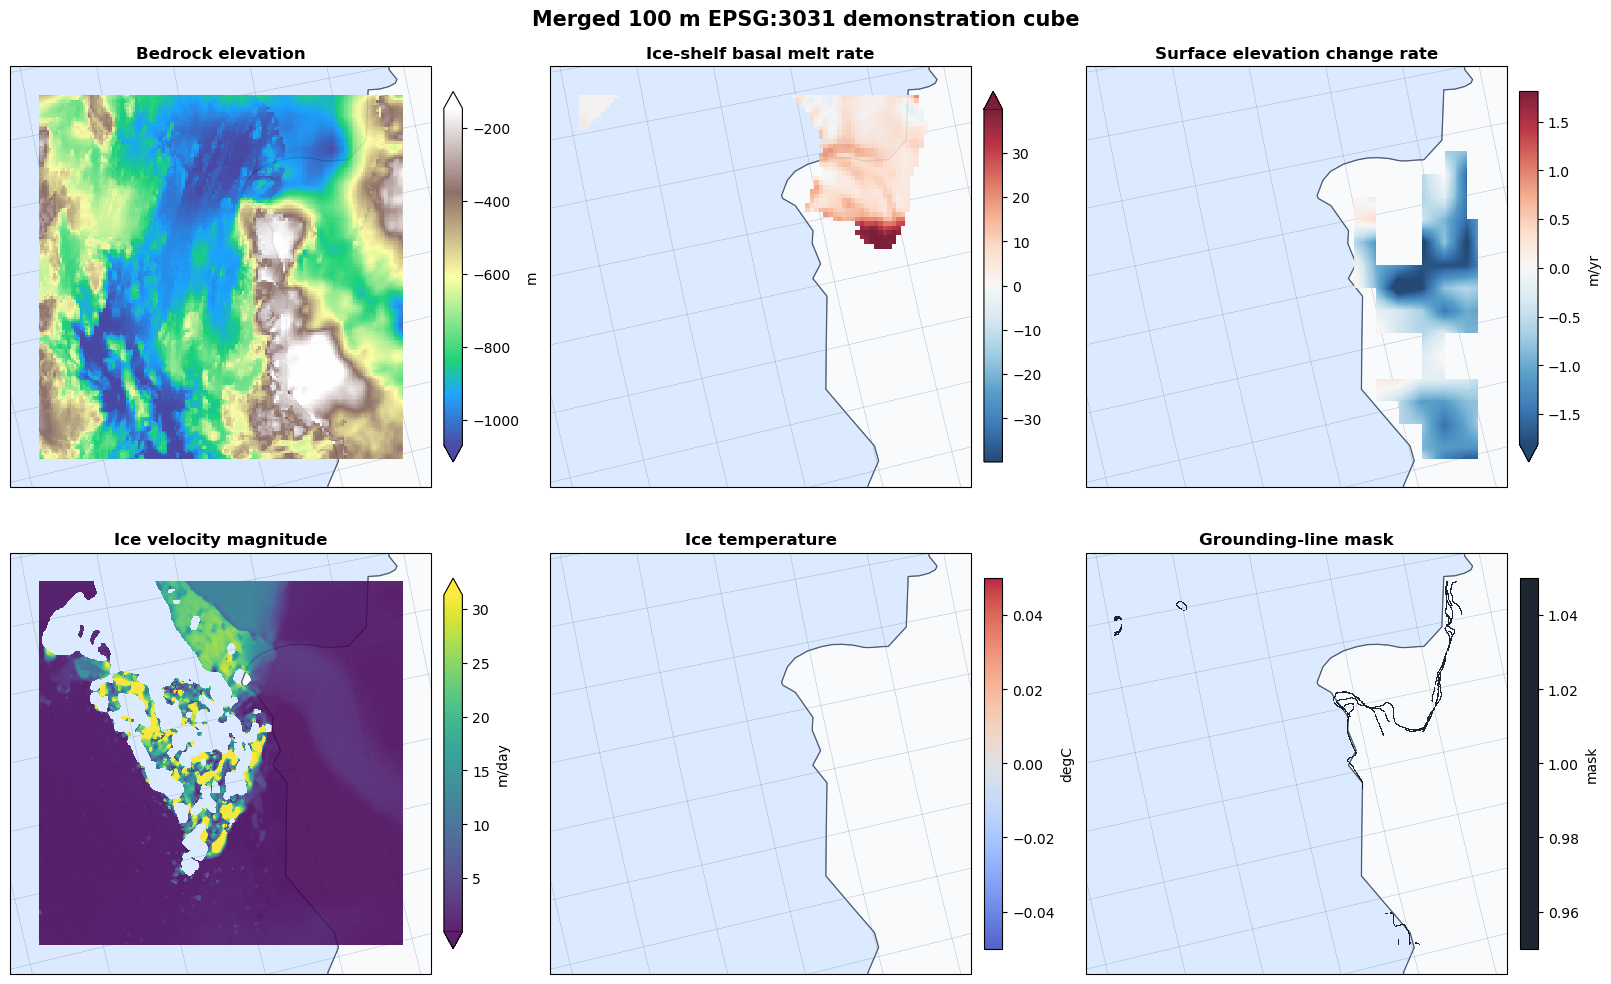

In [22]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

antarctic_crs = ccrs.SouthPolarStereo(
    central_longitude=0,
    true_scale_latitude=-71,
)


plot_specs = {
    "bedrock_elevation": {
        "title": "Bedrock elevation",
        "cmap": "terrain",
        "label": "m",
        "robust": True,
    },
    "ice_shelf_basal_melt_rate": {
        "title": "Ice-shelf basal melt rate",
        "cmap": "RdBu_r",
        "label": demo_cube["ice_shelf_basal_melt_rate"].attrs.get("units", ""),
        "robust": True,
    },
    "surface_elevation_change_rate": {
        "title": "Surface elevation change rate",
        "cmap": "RdBu_r",
        "label": demo_cube["surface_elevation_change_rate"].attrs.get("units", ""),
        "robust": True,
    },
    "ice_velocity_magnitude": {
        "title": "Ice velocity magnitude",
        "cmap": "viridis",
        "label": demo_cube["ice_velocity_magnitude"].attrs.get("units", ""),
        "robust": True,
    },
    "ice_temperature": {
        "title": "Ice temperature",
        "cmap": "coolwarm",
        "label": "degC",
        "robust": True,
    },
    "grounding_line_mask": {
        "title": "Grounding-line mask",
        "cmap": ListedColormap(["#111827"]),
        "label": "mask",
        "robust": False,
    },
}

plot_vars = list(plot_specs)

left = float(demo_cube.x.min())
right = float(demo_cube.x.max())
bottom = float(demo_cube.y.min())
top = float(demo_cube.y.max())

pad_x = (right - left) * 0.08
pad_y = (top - bottom) * 0.08

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10),
    subplot_kw={"projection": antarctic_crs},
    constrained_layout=True,
)

for ax, name in zip(axes.ravel(), plot_vars):
    spec = plot_specs[name]
    da = demo_cube[name]

    if name == "ice_temperature":
        da = da - 273.15
        da.attrs["units"] = "degC"

    if name.endswith("_mask"):
        da = da.where(da > 0)

    ax.set_xlim(left - pad_x, right + pad_x)
    ax.set_ylim(bottom - pad_y, top + pad_y)

    ax.add_feature(cfeature.OCEAN, facecolor="#dbeafe", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#f8fafc", edgecolor="#94a3b8", zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, color="#475569", zorder=2)

    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.35,
        color="#64748b",
        alpha=0.45,
        zorder=3,
    )

    da.plot(
        ax=ax,
        transform=antarctic_crs,
        cmap=spec["cmap"],
        robust=spec["robust"],
        add_colorbar=True,
        cbar_kwargs={
            "label": spec["label"],
            "shrink": 0.78,
            "pad": 0.03,
        },
        alpha=0.88 if not name.endswith("_mask") else 0.95,
        zorder=4,
    )

    ax.set_title(spec["title"], fontsize=12, weight="semibold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_aspect("equal")

fig.suptitle(
    "Merged 100 m EPSG:3031 demonstration cube",
    fontsize=15,
    weight="bold",
)

plt.show()
